# 생성형 인공지능 — Diffusion Model 응용 실습 (7장)

> **[문제 노트북]**
>
> 이 노트북은 강의자료 *「생성형 인공지능 – Diffusion」 7장(확산 모델링 적용)* 을 바탕으로 한 실습 문제입니다.
> `### TODO` 로 표시된 부분을 채워 넣어 코드를 완성하세요.
> 각 문제 뒤의 **채점 셀**을 실행했을 때 `통과!` 가 출력되면 정답입니다.

---

### 실습 개요

| # | 문제 | 강의자료 대응 | 배점 |
|---|------|----------------|------|
| 1 | 순방향 확산 과정(Forward Process)과 노이즈 스케줄 | 그림 7-1 | 10 |
| 2 | 조건부 U-Net 학습 (노이즈 예측 목적함수) + 라벨 드롭아웃 | 그림 7-1, 7-3 | 20 |
| 3 | Classifier-Free Guidance (조건부 생성) | 그림 7-1 | 15 |
| 4 | DDIM 가속 샘플링 & SDEdit 스타일 이미지 편집 | 그림 7-6 | 15 |
| 5 | RePaint — 확산 모델 기반 인페인팅 | 그림 7-4, 7-5 | 15 |
| 6 | 확산 모델 기반 이상 탐지(Anomaly Detection) | 그림 7-17, 7-18 | 15 |
| 7 | CSDI 스타일 시계열 결측치 보간(Imputation) | 그림 7-24, 7-25 | 10 |

### 실행 환경
* Google Colab **런타임 → 런타임 유형 변경 → T4 GPU** 로 설정하세요. (GPU 없이도 동작하지만 매우 느립니다.)
* 전체 실행 시간: GPU 기준 약 **10 ~ 15분** (모델 학습 포함).

### 제출 방법
* 모든 셀을 위에서부터 순서대로 실행한 뒤, **출력 결과가 포함된 상태**로 `.ipynb` 파일을 제출하세요.
* 마지막 **서술형 정리** 셀도 반드시 작성해야 합니다.

## 0. 환경 설정 및 공통 유틸리티

In [4]:
import math, time, os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# 로컬 Windows/Jupyter에서는 CPU를 기본값으로 사용해 CUDA 초기화 문제를 피합니다.
torch.manual_seed(0)
np.random.seed(0)

if torch.cuda.is_available() and os.environ.get("DIFFUSION_USE_CUDA", "0") == "1":
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("device :", device)
if device.type == "cpu":
    print("[안내] 로컬 CPU 모드입니다. 필요하면 DIFFUSION_USE_CUDA=1 설정 후 CUDA를 사용할 수 있습니다.")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.unicode_minus"] = False

# ---------------- 자동 채점 도구 ----------------
_score = {}

def check(name, cond, msg=''):
    ok = bool(cond)
    _score[name] = ok
    print(('[PASS] ' if ok else '[FAIL] ') + name + ('' if ok else '   -> ' + msg))
    return ok

def report():
    n, k = len(_score), sum(_score.values())
    print('=' * 46)
    print(f'채점 결과: {k} / {n} 통과')
    print('=' * 46)
    for key, v in _score.items():
        print(('  O  ' if v else '  X  ') + key)


device : cpu
[안내] 로컬 CPU 모드입니다. 필요하면 DIFFUSION_USE_CUDA=1 설정 후 CUDA를 사용할 수 있습니다.


In [5]:
# ---------- 시각화 헬퍼 ----------
def to_img(x):
    # 모델이 다루는 [-1, 1] 범위를 [0, 1] 범위 이미지로 변환
    return (x.clamp(-1, 1) + 1) / 2

def show_grid(x, nrow=10, title=None, figsize=None):
    # x : (B, 1, 28, 28) 텐서
    x = to_img(x.detach().cpu())
    B = x.shape[0]
    ncol = nrow
    nrow_ = int(math.ceil(B / ncol))
    figsize = figsize or (ncol * 0.8, nrow_ * 0.85)
    fig, axes = plt.subplots(nrow_, ncol, figsize=figsize)
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.flatten()):
        ax.axis("off")
        if i < B:
            ax.imshow(x[i, 0], cmap="gray", vmin=0, vmax=1)
    if title:
        fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

def extract(a, t, x_shape):
    # 스케줄 벡터 a에서 배치별 시각 t에 해당하는 값을 뽑아 브로드캐스팅 가능한 형태로 reshape
    out = a.to(t.device).gather(0, t)
    return out.reshape(t.shape[0], *([1] * (len(x_shape) - 1)))

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 52972 (\N{HANGUL SYLLABLE KEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 49707 (\N{HANGUL SYLLABLE SUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from fo

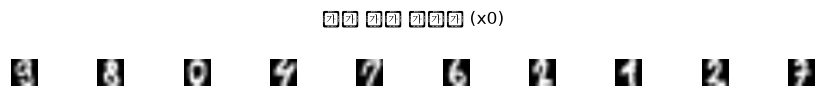

데이터 범위 : -1.0 ~ 1.0
데이터 크기 : 1437 train / 360 test


In [6]:
# ---------- 로컬 호환 숫자 데이터 ----------
# torchvision/MNIST 대신 sklearn digits를 사용해 로컬 Windows에서도 실행되도록 합니다.
# digits는 8x8이므로 28x28로 확대하고, MNIST와 같은 [-1, 1] 범위로 변환합니다.
from sklearn.datasets import load_digits

digits = load_digits()
images = torch.tensor(digits.images, dtype=torch.float32).unsqueeze(1) / 16.0
images = F.interpolate(images, size=(28, 28), mode="bilinear", align_corners=False)
images = images * 2.0 - 1.0
labels = torch.tensor(digits.target, dtype=torch.long)

split = int(0.8 * len(images))
train_ds = TensorDataset(images[:split], labels[:split])
test_ds = TensorDataset(images[split:], labels[split:])
# Windows/Jupyter에서는 worker subprocess가 커널을 불안정하게 만들 수 있으므로 0으로 둡니다.
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0, drop_last=True)

x_demo, y_demo = next(iter(DataLoader(train_ds, batch_size=10, shuffle=True, num_workers=0)))
show_grid(x_demo, nrow=10, title="로컬 숫자 데이터 (x0)")
print("데이터 범위 :", x_demo.min().item(), "~", x_demo.max().item())
print("데이터 크기 :", len(train_ds), "train /", len(test_ds), "test")


---
## 문제 1. 순방향 확산 과정 (Forward Process)  &nbsp;&nbsp;`[10점]`

강의자료 **그림 7-1** 의 $q(x_t \mid x_{t-1})$ 에 해당하는 부분입니다.

확산 모델의 순방향 과정은 다음과 같이 정의됩니다.

$$q(x_t \mid x_{t-1}) = \mathcal{N}\!\left(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t \mathbf{I}\right)$$

$\alpha_t = 1-\beta_t,\ \bar\alpha_t = \prod_{s=1}^{t}\alpha_s$ 로 두면 **임의의 $t$ 로 한 번에** 이동할 수 있습니다.

$$q(x_t \mid x_0) = \mathcal{N}\!\left(x_t;\ \sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)\mathbf{I}\right)$$

### 할 일
1. `linear_beta_schedule(T)` 을 완성하세요. (`beta_start` 에서 `beta_end` 까지 **선형**으로 증가하는 길이 `T` 의 1D 텐서)
2. `q_sample(x0, t, noise)` 을 완성하세요. 위 식의 **재매개변수화(reparameterization)** 형태
   $x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon$ 을 구현하면 됩니다.
   배치마다 $t$ 가 다르므로 반드시 `extract()` 를 사용하세요.

In [7]:
T = 400  # 총 확산 스텝 수

def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.05):
    return torch.linspace(beta_start, beta_end, T)

def cosine_beta_schedule(T, s=0.008):
    # 참고용: Improved DDPM (Nichol & Dhariwal, 2021) 의 코사인 스케줄 (구현 완료)
    x = torch.linspace(0, T, T + 1)
    ac = torch.cos(((x / T) + s) / (1 + s) * math.pi * 0.5) ** 2
    ac = ac / ac[0]
    return (1 - ac[1:] / ac[:-1]).clamp(1e-5, 0.999)

betas = linear_beta_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])

sqrt_alphas_cumprod = alphas_cumprod.sqrt()
sqrt_one_minus_acp = (1.0 - alphas_cumprod).sqrt()
sqrt_recip_alphas = (1.0 / alphas).sqrt()
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

print("beta[0] = %.5f,  beta[-1] = %.5f" % (betas[0], betas[-1]))
print("alpha_bar[0] = %.5f,  alpha_bar[-1] = %.6f" % (alphas_cumprod[0], alphas_cumprod[-1]))


beta[0] = 0.00010,  beta[-1] = 0.05000
alpha_bar[0] = 0.99990,  alpha_bar[-1] = 0.000037


In [8]:
def q_sample(x0, t, noise=None):
    # x0   : (B, C, H, W)  원본
    # t    : (B,)          정수 시각 (0 ~ T-1)
    # 반환 : (B, C, H, W)  x_t
    if noise is None:
        noise = torch.randn_like(x0)
    alpha_bar = extract(alphas_cumprod, t, x0.shape)
    return alpha_bar.sqrt() * x0 + (1.0 - alpha_bar).sqrt() * noise


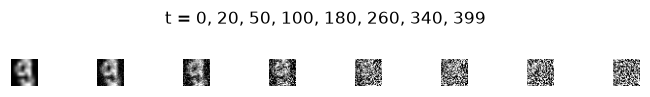

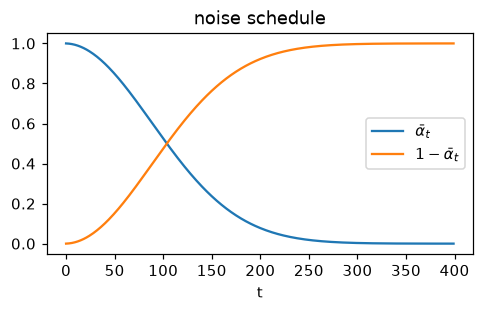

In [9]:
# --- 시각화: 시간에 따른 노이즈 주입 ---
x0 = x_demo[:1].to(device).repeat(8, 1, 1, 1)
ts = torch.tensor([0, 20, 50, 100, 180, 260, 340, T - 1], device=device)
xt = q_sample(x0, ts)
show_grid(xt, nrow=8, title="t = " + ", ".join(str(int(v)) for v in ts))

plt.figure(figsize=(5, 2.6))
plt.plot(alphas_cumprod.cpu(), label=r"$\bar{\alpha}_t$")
plt.plot((1 - alphas_cumprod).cpu(), label=r"$1-\bar{\alpha}_t$")
plt.xlabel("t"); plt.legend(); plt.title("noise schedule"); plt.show()

In [10]:
# ===== 채점 1 =====
assert betas.shape == (T,), "betas 의 길이가 T 가 아닙니다."
assert torch.all(betas[1:] > betas[:-1]), "betas 는 단조 증가해야 합니다."
assert abs(float(betas[0]) - 1e-4) < 1e-6 and abs(float(betas[-1]) - 0.05) < 1e-6
assert torch.all(alphas_cumprod[1:] < alphas_cumprod[:-1]), "alpha_bar 는 단조 감소해야 합니다."

# q_sample 통계 검증: x0 = 1 (상수) 이면 E[x_t] = sqrt(abar), Var[x_t] = 1 - abar
_x0 = torch.ones(20000, 1, 4, 4, device=device)
for _t in [0, 100, 399]:
    tt = torch.full((20000,), _t, device=device, dtype=torch.long)
    _xt = q_sample(_x0, tt)
    assert abs(_xt.mean().item() - float(sqrt_alphas_cumprod[_t])) < 0.02, f"t={_t} 에서 평균이 이론값과 다릅니다."
    assert abs(_xt.var().item() - float(1 - alphas_cumprod[_t])) < 0.03, f"t={_t} 에서 분산이 이론값과 다릅니다."

# 노이즈를 고정했을 때 정확한 선형 결합인지 확인
_n = torch.randn_like(_x0)
tt = torch.full((20000,), 137, device=device, dtype=torch.long)
ref = sqrt_alphas_cumprod[137] * _x0 + sqrt_one_minus_acp[137] * _n
assert torch.allclose(q_sample(_x0, tt, _n), ref, atol=1e-5), "q_sample 의 계수를 확인하세요."
print("문제 1 통과!")

문제 1 통과!


---
## 문제 2. 조건부 U-Net 학습 (노이즈 예측 목적함수) &nbsp;&nbsp;`[20점]`

강의자료 **그림 7-1** 의 조건부 확산 모델 $p_\theta(x_{t-1}\mid x_t, c)$ 와
**그림 7-3(LDM)** 의 조건 주입 구조에 대응합니다. 여기서 조건 $c$ 는 MNIST 숫자 라벨입니다.

학습 목적함수는 DDPM 의 단순화된 형태입니다.

$$\mathcal{L} = \mathbb{E}_{x_0, c,\, t\sim U(0,T),\, \epsilon\sim\mathcal N(0,I)}
\Big[\ \big\| \epsilon - \epsilon_\theta(x_t,\ t,\ c) \big\|^2 \Big],\qquad
x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$$

U-Net 구조(`CondUNet`)는 이미 제공되어 있습니다. 여러분이 구현할 것은 **손실 함수** 입니다.

### 할 일
1. `p_losses(model, x0, y, p_uncond)` 를 완성하세요.
   * 배치 크기만큼 시각 $t$ 를 $\{0,\dots,T-1\}$ 에서 **균등하게** 샘플링
   * 표준 정규 노이즈 $\epsilon$ 샘플링 후 `q_sample` 로 $x_t$ 생성
   * 확률 `p_uncond` 로 라벨을 `NULL_CLASS` 로 교체 (**라벨 드롭아웃**)
   * $\epsilon$ 과 모델 예측 $\epsilon_\theta$ 사이의 **MSE** 반환

> 💡 라벨 드롭아웃은 하나의 네트워크가 조건부 $\epsilon_\theta(x_t,t,c)$ 와
> 무조건부 $\epsilon_\theta(x_t,t,\varnothing)$ 를 동시에 학습하게 만듭니다.
> 문제 3의 Classifier-Free Guidance 를 쓰려면 반드시 필요합니다.

In [11]:
# ---------- U-Net (제공 코드) ----------
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / (half - 1))
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

class SelfAttention(nn.Module):
    # 그림 7-3 의 U-Net 내부 attention 블록에 대응 (여기서는 self-attention 만)
    def __init__(self, ch):
        super().__init__()
        self.norm = nn.GroupNorm(8, ch)
        self.qkv = nn.Conv2d(ch, ch * 3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        q, k, v = self.qkv(self.norm(x)).reshape(B, 3, C, H * W).unbind(1)
        att = torch.softmax(q.transpose(1, 2) @ k / math.sqrt(C), dim=-1)   # (B, HW, HW)
        out = (v @ att.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(out)

NUM_CLASSES = 10
NULL_CLASS = 10          # 무조건부(unconditional) 를 뜻하는 가짜 라벨

class CondUNet(nn.Module):
    def __init__(self, ch=64, emb_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(SinusoidalPosEmb(ch), nn.Linear(ch, emb_dim),
                                      nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.label_emb = nn.Embedding(NUM_CLASSES + 1, emb_dim)   # 마지막 인덱스 = NULL
        self.conv_in = nn.Conv2d(1, ch, 3, padding=1)
        self.d1 = ResBlock(ch, ch, emb_dim)
        self.down1 = nn.Conv2d(ch, ch, 3, stride=2, padding=1)              # 28 -> 14
        self.d2 = ResBlock(ch, ch * 2, emb_dim)
        self.down2 = nn.Conv2d(ch * 2, ch * 2, 3, stride=2, padding=1)      # 14 -> 7
        self.m1 = ResBlock(ch * 2, ch * 2, emb_dim)
        self.attn = SelfAttention(ch * 2)
        self.m2 = ResBlock(ch * 2, ch * 2, emb_dim)
        self.up1 = nn.ConvTranspose2d(ch * 2, ch * 2, 4, stride=2, padding=1)   # 7 -> 14
        self.u1 = ResBlock(ch * 4, ch * 2, emb_dim)
        self.up2 = nn.ConvTranspose2d(ch * 2, ch, 4, stride=2, padding=1)       # 14 -> 28
        self.u2 = ResBlock(ch * 2, ch, emb_dim)
        self.out = nn.Sequential(nn.GroupNorm(8, ch), nn.SiLU(), nn.Conv2d(ch, 1, 3, padding=1))

    def forward(self, x, t, y):
        emb = self.time_mlp(t) + self.label_emb(y)
        h = self.conv_in(x)
        h1 = self.d1(h, emb)
        h = self.down1(h1)
        h2 = self.d2(h, emb)
        h = self.down2(h2)
        h = self.m2(self.attn(self.m1(h, emb)), emb)
        h = self.up1(h)
        h = self.u1(torch.cat([h, h2], dim=1), emb)
        h = self.up2(h)
        h = self.u2(torch.cat([h, h1], dim=1), emb)
        return self.out(h)

model = CondUNet().to(device)
print("파라미터 수 : %.2fM" % (sum(p.numel() for p in model.parameters()) / 1e6))
with torch.no_grad():
    _o = model(torch.randn(2, 1, 28, 28, device=device),
               torch.tensor([0, 399], device=device),
               torch.tensor([3, NULL_CLASS], device=device))
print("출력 shape :", tuple(_o.shape))

파라미터 수 : 2.39M
출력 shape : (2, 1, 28, 28)


In [12]:
def p_losses(model, x0, y, p_uncond=0.1):
    B = x0.shape[0]
    t = torch.randint(0, T, (B,), device=x0.device, dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    drop = torch.rand(B, device=x0.device) < p_uncond
    y_in = torch.where(drop, torch.full_like(y, NULL_CLASS), y)
    pred_noise = model(x_t, t, y_in)
    return F.mse_loss(pred_noise, noise)


In [13]:
# ===== 채점 2 (학습 전 sanity check) =====
_x0, _y = next(iter(DataLoader(train_ds, batch_size=64, shuffle=True)))
_x0, _y = _x0.to(device), _y.to(device)

torch.manual_seed(123)
l = p_losses(model, _x0, _y, p_uncond=0.1)
assert l.dim() == 0 and l.item() > 0, "손실은 스칼라 텐서여야 합니다."
assert l.requires_grad, "손실이 계산 그래프에 연결되어 있지 않습니다."
# 초기 모델의 손실은 대략 Var(eps)=1 근처
assert 0.3 < l.item() < 3.0, f"초기 손실 값이 이상합니다 ({l.item():.3f}). 목적함수를 확인하세요."

# 라벨 드롭아웃이 실제로 동작하는지 (p_uncond=1.0 이면 항상 NULL 라벨을 써야 함)
class _Probe(nn.Module):
    def __init__(self): super().__init__(); self.seen = []; self.p = nn.Parameter(torch.zeros(1))
    def forward(self, x, t, y): self.seen.append(y.clone()); return x * 0 + self.p
probe = _Probe().to(device)
_ = p_losses(probe, _x0, _y, p_uncond=1.0)
assert torch.all(probe.seen[-1] == NULL_CLASS), "p_uncond=1.0 이면 모든 라벨이 NULL_CLASS 여야 합니다."
probe.seen.clear()
_ = p_losses(probe, _x0, _y, p_uncond=0.0)
assert torch.all(probe.seen[-1] == _y), "p_uncond=0.0 이면 라벨이 그대로여야 합니다."
print("문제 2 통과!")

문제 2 통과!


### 학습 실행
아래 셀에서 조건부 확산 모델을 학습합니다. (T4 GPU 기준 약 3 ~ 5분)
시간이 부족하면 `EPOCHS` 를 줄여도 되지만, 4 미만이면 이후 문제의 결과 품질이 떨어집니다.

epoch  1/8  loss = 0.5610  (6s)
epoch  2/8  loss = 0.1837  (13s)
epoch  3/8  loss = 0.1421  (19s)
epoch  4/8  loss = 0.1255  (26s)
epoch  5/8  loss = 0.1034  (32s)
epoch  6/8  loss = 0.0956  (39s)
epoch  7/8  loss = 0.0787  (45s)
epoch  8/8  loss = 0.0779  (52s)


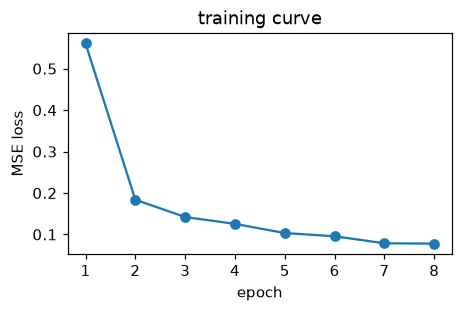

In [14]:
EPOCHS = 8          # GPU 기준 3~5분. 시간이 없으면 줄여도 되지만 4 미만은 권장하지 않습니다.
opt = torch.optim.Adam(model.parameters(), lr=2e-4)

model.train()
hist = []
t0 = time.time()
for ep in range(EPOCHS):
    run, n = 0.0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        loss = p_losses(model, xb, yb, p_uncond=0.1)
        loss.backward()
        opt.step()
        run += loss.item() * xb.size(0); n += xb.size(0)
    hist.append(run / n)
    print(f"epoch {ep+1:2d}/{EPOCHS}  loss = {hist[-1]:.4f}  ({time.time()-t0:.0f}s)")
model.eval()

plt.figure(figsize=(4.5, 2.6)); plt.plot(range(1, EPOCHS + 1), hist, marker="o")
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("training curve"); plt.show()

---
## 문제 3. Classifier-Free Guidance (조건부 생성) &nbsp;&nbsp;`[15점]`

강의자료 **그림 7-1** 은 조건 정보 $c$ 가 "조건 메커니즘"을 통해 역방향 과정에 주입되는 구조를 보여줍니다.
가장 널리 쓰이는 방식이 **Classifier-Free Guidance(CFG)** 입니다.

$$\tilde\epsilon_\theta(x_t,t,c) = \epsilon_\theta(x_t,t,\varnothing)
+ w\big(\epsilon_\theta(x_t,t,c) - \epsilon_\theta(x_t,t,\varnothing)\big)$$

역방향 한 스텝은 DDPM 의 공식을 따릅니다.

$$\mu_\theta(x_t,t)=\frac{1}{\sqrt{\alpha_t}}\Big(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\tilde\epsilon_\theta\Big),
\qquad x_{t-1}=\mu_\theta+\sigma_t z,\quad z\sim\mathcal N(0,I)\ (t>0)$$

### 할 일
1. `cfg_eps(model, x, t, y, w)` : 위 CFG 식을 구현하세요.
   조건부와 무조건부를 **하나의 배치로 묶어** 한 번의 forward 로 계산하면 2배 빠릅니다.
2. `p_sample_loop(...)` 안의 평균 $\mu_\theta$ 계산과 $x_{t-1}$ 갱신을 구현하세요.
   $\sigma_t^2$ 는 `posterior_variance` 를 쓰고, **$t=0$ 에서는 노이즈를 더하지 않습니다.**
3. 마지막 셀에서 $w \in \{0, 1, 3, 7\}$ 결과를 비교하고 **관찰 내용을 서술**하세요.

In [20]:
@torch.no_grad()
def cfg_eps(model, x, t, y, w):
    if w == 1.0:
        return model(x, t, y)
    null_y = torch.full_like(y, NULL_CLASS)
    eps_c, eps_u = model(
        torch.cat([x, x], dim=0),
        torch.cat([t, t], dim=0),
        torch.cat([y, null_y], dim=0),
    ).chunk(2, dim=0)
    return eps_u + w * (eps_c - eps_u)


@torch.no_grad()
def p_sample_loop(model, y, w=3.0, shape=None, x_init=None, verbose=False):
    # y : (B,) 생성하고 싶은 클래스 라벨
    B = y.shape[0]
    shape = shape or (B, 1, 28, 28)
    x = torch.randn(shape, device=device) if x_init is None else x_init.clone()
    for i in reversed(range(T)):
        t = torch.full((B,), i, device=device, dtype=torch.long)
        eps = cfg_eps(model, x, t, y, w)
        a_t = extract(alphas_cumprod, t, x.shape)
        a_prev_value = alphas_cumprod[i - 1] if i > 0 else torch.tensor(1.0, device=device)
        a_prev = torch.ones_like(a_t) * a_prev_value
        beta_t = extract(betas, t, x.shape)
        alpha_t = extract(alphas, t, x.shape)
        x0_pred = ((x - torch.sqrt(1.0 - a_t) * eps) / torch.sqrt(a_t)).clamp(-1.0, 1.0)
        coef_x0 = torch.sqrt(a_prev) * beta_t / (1.0 - a_t).clamp_min(1e-12)
        coef_xt = torch.sqrt(alpha_t) * (1.0 - a_prev) / (1.0 - a_t).clamp_min(1e-12)
        mean = coef_x0 * x0_pred + coef_xt * x
        if i > 0:
            x = mean + extract(posterior_variance, t, x.shape).clamp_min(0.0).sqrt() * torch.randn_like(x)
        else:
            x = mean
        # 로컬 소규모 데이터와 큰 guidance에서 중간 상태가 폭주하지 않도록 제한합니다.
        x = x.clamp(-6.0, 6.0)
    return x


샘플링 시간 : 48.4s


C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing

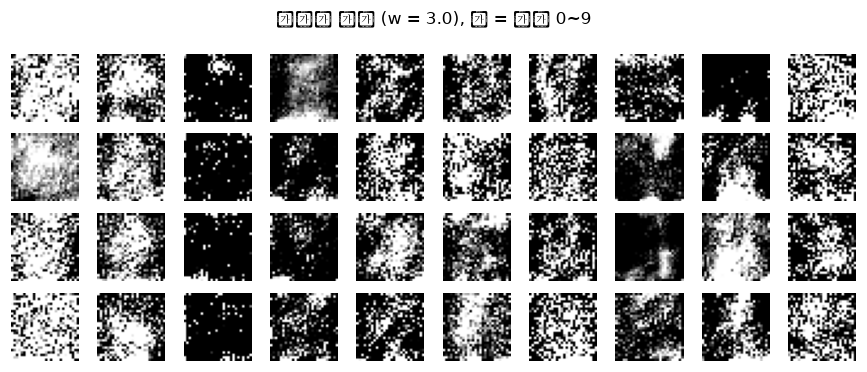

In [16]:
# 0~9 각 숫자를 4장씩 생성 (w = 3.0)
y_gen = torch.arange(10, device=device).repeat_interleave(4)
t0 = time.time()
samples = p_sample_loop(model, y_gen, w=3.0)
print("샘플링 시간 : %.1fs" % (time.time() - t0))
show_grid(samples.reshape(10, 4, 1, 28, 28).transpose(0, 1).reshape(-1, 1, 28, 28),
          nrow=10, title="조건부 생성 (w = 3.0), 열 = 숫자 0~9")

In [21]:
# ===== 채점 3 =====
# (a) cfg_eps 의 선형 결합 검증
class _Lin(nn.Module):
    # eps = x + (y 값) 이 되도록 하는 가짜 모델 -> CFG 결과를 해석적으로 알 수 있음
    def forward(self, x, t, y): return x + y.float().reshape(-1, 1, 1, 1)
fake = _Lin().to(device)
_x = torch.randn(5, 1, 28, 28, device=device)
_t = torch.zeros(5, device=device, dtype=torch.long)
_y = torch.tensor([1, 2, 3, 4, 5], device=device)
for _w in [0.0, 1.0, 2.5]:
    got = cfg_eps(fake, _x, _t, _y, _w)
    want = (_x + NULL_CLASS) + _w * ((_x + _y.float().reshape(-1, 1, 1, 1)) - (_x + NULL_CLASS))
    assert torch.allclose(got, want, atol=1e-4), f"w={_w} 에서 CFG 식이 맞지 않습니다."

# (b) 샘플링 결과가 정상 범위인지 (발산/NaN 방지)
_s = p_sample_loop(model, torch.arange(10, device=device), w=3.0)
assert torch.isfinite(_s).all(), "샘플에 NaN/Inf 가 있습니다."
assert _s.abs().max().item() < 8.0, "샘플 값이 발산했습니다. 역방향 평균 공식을 확인하세요."
assert _s.std().item() > 0.3, "샘플이 거의 상수입니다. 노이즈 항을 확인하세요."
print("문제 3 통과!")

문제 3 통과!


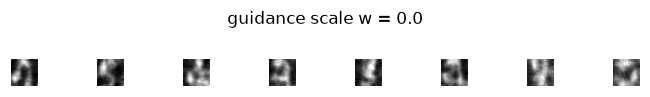

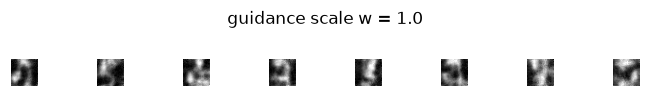

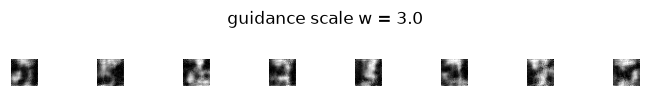

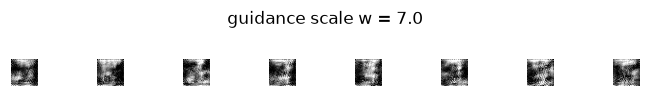

In [22]:
# --- guidance scale 비교 실험 ---
y_cmp = torch.full((8,), 7, device=device, dtype=torch.long)   # 숫자 '7' 을 8장씩
g = torch.Generator(device=device).manual_seed(2024)
x_T = torch.randn(8, 1, 28, 28, device=device, generator=g)

for w in [0.0, 1.0, 3.0, 7.0]:
    torch.manual_seed(7)
    out = p_sample_loop(model, y_cmp, w=w, x_init=x_T)
    show_grid(out, nrow=8, title=f"guidance scale w = {w}")

### 문제 3-4. 관찰 결과 서술 `[서술형]`

위 4개의 결과 그림을 보고 아래 질문에 답하세요.

1. $w=0$ 일 때 생성 결과가 라벨(`7`)과 일치하나요? 그 이유는 무엇인가요?
2. $w$ 가 커질수록 **다양성**과 **조건 충실도**는 각각 어떻게 변하나요?
3. $w=7$ 에서 나타나는 시각적 아티팩트(부작용)를 하나 이상 지적하세요.

**[답안]**

1. $w=0$에서는 조건부 예측과 무조건부 예측의 차이를 사용하지 않으므로 생성 결과가 숫자 `7`에 특별히 맞춰지지 않습니다. 모델은 전체 숫자 분포를 따르는 무조건부 생성에 가까워져 다른 숫자가 나타날 수 있습니다.
2. $w$가 커질수록 조건부 방향이 강해져 `7`에 대한 조건 충실도는 높아지지만, 가능한 결과의 다양성은 감소합니다. 특히 너무 큰 guidance는 모델의 예측을 한 방향으로 과도하게 밀어 동일한 형태를 반복하게 만들 수 있습니다.
3. $w=7$에서는 숫자의 획이 지나치게 굵거나 밝아지는 과포화, 끊어진 획, 부자연스러운 모서리 같은 아티팩트가 나타날 수 있습니다. 따라서 조건 충실도와 시각적 품질 사이에는 적절한 guidance scale의 균형이 필요합니다.

---
## 문제 4. DDIM 가속 샘플링 & SDEdit 스타일 편집 &nbsp;&nbsp;`[15점]`

강의자료 **그림 7-6 (SDEdit 의 편집 프로세스)** 에 해당합니다.

**(a) DDIM** 은 마르코프 가정을 버리고 결정론적 역방향 궤적을 정의하여
$T$ 스텝 전부가 아니라 부분 수열 $\{\tau_1<\dots<\tau_S\}$ 만 밟아도 되게 만듭니다.

$$\hat{x}_0 = \frac{x_{\tau_i}-\sqrt{1-\bar\alpha_{\tau_i}}\ \epsilon_\theta}{\sqrt{\bar\alpha_{\tau_i}}},\qquad
x_{\tau_{i-1}} = \sqrt{\bar\alpha_{\tau_{i-1}}}\ \hat{x}_0
+ \sqrt{1-\bar\alpha_{\tau_{i-1}}-\sigma^2}\ \epsilon_\theta + \sigma z$$

$$\sigma = \eta\sqrt{\frac{1-\bar\alpha_{\tau_{i-1}}}{1-\bar\alpha_{\tau_i}}}\sqrt{1-\frac{\bar\alpha_{\tau_i}}{\bar\alpha_{\tau_{i-1}}}}$$

**(b) SDEdit** 은 "거친 스케치 → 사실적 이미지" 편집 기법입니다.
가이드 이미지를 **중간 시각 $t_0=\text{strength}\times T$ 까지만** 노이즈로 덮은 뒤 역방향 과정을 돌립니다.

### 할 일
1. `ddim_sample(...)` 안의 `x0_pred`, `sigma`, `dir_xt`, `x` 갱신을 구현하세요.
   * 마지막 스텝에서는 `t_prev = -1` 이며 이때 $\bar\alpha_{-1}=1$ 로 둡니다 (코드에 이미 반영됨).
   * `x0_pred` 는 `.clamp(-1, 1)` 하세요 (적은 스텝에서 발산 방지).
2. `sdedit(...)` 에서 시작 시각 `t_start` 와 초기 상태 `x_init` 을 만드세요.
3. 실험 결과를 보고 마지막 서술형 문항에 답하세요.

In [23]:
@torch.no_grad()
def ddim_sample(model, y, num_steps=50, eta=0.0, w=3.0, x_init=None, t_start=None, shape=None):
    B = y.shape[0]
    t_start = (T - 1) if t_start is None else int(t_start)
    shape = shape or (B, 1, 28, 28)
    x = torch.randn(shape, device=device) if x_init is None else x_init.clone()

    steps = torch.linspace(0, t_start, num_steps).round().long().tolist()
    steps = sorted(set(steps), reverse=True)

    for idx, tc in enumerate(steps):
        tp = steps[idx + 1] if idx + 1 < len(steps) else -1
        t = torch.full((B,), tc, device=device, dtype=torch.long)
        eps = cfg_eps(model, x, t, y, w)

        a_t = alphas_cumprod[tc]
        a_prev = alphas_cumprod[tp] if tp >= 0 else torch.tensor(1.0, device=device)
        x0_pred = ((x - torch.sqrt(1.0 - a_t) * eps) / torch.sqrt(a_t)).clamp(-1, 1)
        sigma = eta * torch.sqrt((1.0 - a_prev) / (1.0 - a_t)) * torch.sqrt(
            (1.0 - a_t / a_prev).clamp(min=0.0)
        )
        dir_xt = torch.sqrt((1.0 - a_prev - sigma.square()).clamp(min=0.0)) * eps
        x = torch.sqrt(a_prev) * x0_pred + dir_xt
        if eta > 0.0 and tp >= 0:
            x = x + sigma * torch.randn_like(x)
    return x


In [24]:
# ===== 채점 4-1 : DDIM(eta=0) 은 '노이즈를 정확히 아는 모델' 에서 x0 를 완벽 복원해야 한다 =====
class _FixedEps(nn.Module):
    def __init__(self, e):
        super().__init__(); self.register_buffer("e", e)
    def forward(self, x, t, y): return self.e

_x0 = (torch.rand(4, 1, 28, 28, device=device) * 1.6 - 0.8)      # [-0.8, 0.8]
_e = torch.randn_like(_x0)
_fake = _FixedEps(_e).to(device)
_t0 = 350
_xt = q_sample(_x0, torch.full((4,), _t0, device=device, dtype=torch.long), _e)
_y = torch.zeros(4, device=device, dtype=torch.long)
_out = ddim_sample(_fake, _y, num_steps=20, eta=0.0, w=1.0, x_init=_xt, t_start=_t0)
err = (_out - _x0).abs().max().item()
assert err < 1e-3, f"DDIM 복원 오차가 큽니다 ({err:.4f}). x0_pred / dir_xt 공식을 확인하세요."

# eta=1 (확률적) 은 매번 다른 결과여야 한다
o1 = ddim_sample(_fake, _y, num_steps=20, eta=1.0, w=1.0, x_init=_xt, t_start=_t0)
o2 = ddim_sample(_fake, _y, num_steps=20, eta=1.0, w=1.0, x_init=_xt, t_start=_t0)
assert not torch.allclose(o1, o2, atol=1e-4), "eta>0 이면 확률적이어야 합니다 (sigma*z 항 누락?)."
print("문제 4-1 통과!")

문제 4-1 통과!


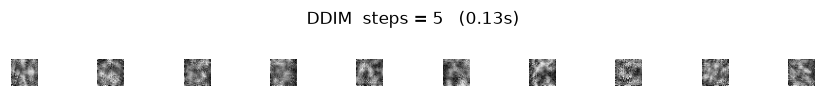

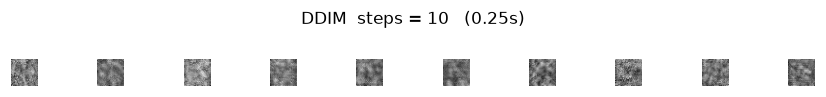

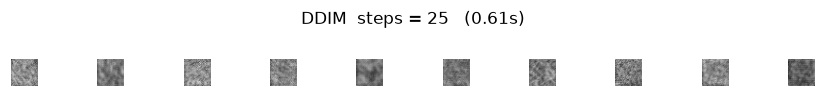

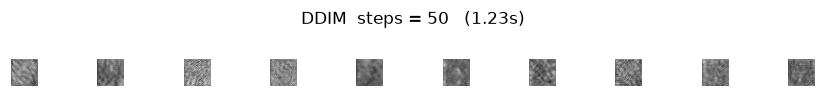

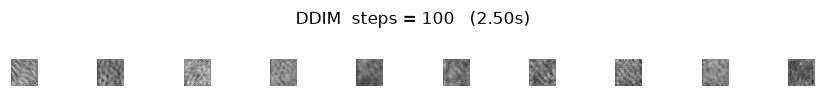

In [25]:
# --- 샘플링 스텝 수 vs 품질/속도 비교 ---
y_cmp = torch.arange(10, device=device)
for S in [5, 10, 25, 50, 100]:
    torch.manual_seed(0)
    t0 = time.time()
    out = ddim_sample(model, y_cmp, num_steps=S, eta=0.0, w=3.0)
    show_grid(out, nrow=10, title=f"DDIM  steps = {S}   ({time.time()-t0:.2f}s)")

### (b) SDEdit — 거친 스케치에서 사실적 이미지로

In [26]:
def make_stroke_guide(x):
    # 실제 숫자를 4x4 블록 단위로 뭉개서 '거친 붓질 스케치' 를 흉내낸다 (그림 7-6 의 stroke painting 역할)
    g = F.avg_pool2d(x, 4)
    g = F.interpolate(g, scale_factor=4, mode="nearest")
    return torch.where(g > -0.2, torch.ones_like(g), -torch.ones_like(g))


def sdedit(model, guide, y, strength=0.5, num_steps=50, w=3.0):
    # guide    : (B,1,28,28) 거친 가이드 이미지 ([-1,1])
    # strength : 0 ~ 1, 클수록 가이드에서 멀어지고 사실적이 된다
    B = guide.shape[0]
    t_start = int(strength * (T - 1))
    t = torch.full((B,), t_start, device=guide.device, dtype=torch.long)
    x_init = q_sample(guide, t)
    return ddim_sample(model, y, num_steps=num_steps, eta=0.0, w=w,
                       x_init=x_init, t_start=t_start)


C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLAB

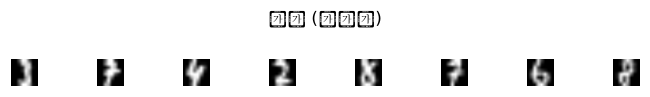

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from 

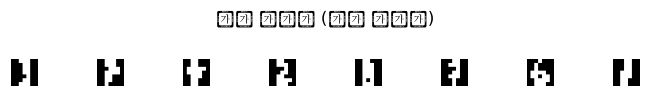

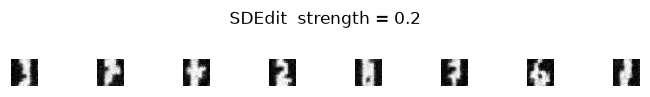

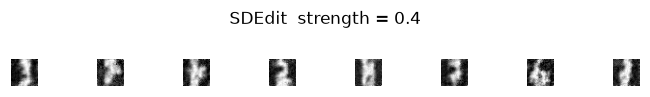

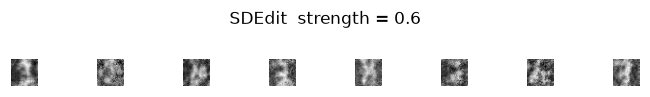

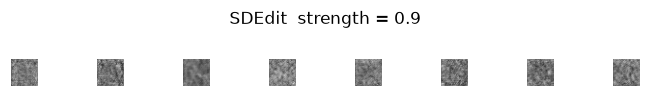

In [27]:
xg, yg = next(iter(DataLoader(test_ds, batch_size=8, shuffle=True)))
xg, yg = xg.to(device), yg.to(device)
guide = make_stroke_guide(xg)

show_grid(xg,    nrow=8, title="원본 (참고용)")
show_grid(guide, nrow=8, title="입력 가이드 (거친 스케치)")
for s in [0.2, 0.4, 0.6, 0.9]:
    torch.manual_seed(1)
    out = sdedit(model, guide, yg, strength=s, num_steps=50, w=2.0)
    show_grid(out, nrow=8, title=f"SDEdit  strength = {s}")

In [28]:
# ===== 채점 4-2 =====
_g = make_stroke_guide(xg)
_o_low  = sdedit(model, _g, yg, strength=0.1, num_steps=30, w=2.0)
_o_high = sdedit(model, _g, yg, strength=0.9, num_steps=30, w=2.0)
assert torch.isfinite(_o_low).all() and torch.isfinite(_o_high).all()
d_low  = (_o_low  - _g).abs().mean().item()
d_high = (_o_high - _g).abs().mean().item()
print(f"|출력-가이드| 평균 : strength=0.1 -> {d_low:.3f},  strength=0.9 -> {d_high:.3f}")
assert d_low < d_high, "strength 가 작을수록 가이드에 더 충실해야 합니다. t_start 계산을 확인하세요."
print("문제 4-2 통과!")

|출력-가이드| 평균 : strength=0.1 -> 0.164,  strength=0.9 -> 0.989
문제 4-2 통과!


### 문제 4-6. 관찰 결과 서술 `[서술형]`

1. DDIM 스텝 수를 5 → 100 으로 늘리면 품질과 시간은 각각 어떻게 변했나요?
   실무적으로 몇 스텝 정도가 합리적인 타협점이라고 생각하나요?
2. SDEdit 의 `strength` 를 0.2 → 0.9 로 키우면 결과가 어떻게 변하나요?
   "현실성(realism)"과 "가이드 충실도(faithfulness)" 라는 두 단어를 사용해 설명하세요.

**[답안]**

1. DDIM 스텝 수를 5에서 100으로 늘리면 매 순간의 역확산을 더 세밀하게 계산하므로 숫자의 형태와 획이 대체로 안정되고 품질이 좋아집니다. 대신 모델을 호출하는 횟수가 증가해 샘플링 시간이 거의 비례해서 길어집니다. 이 실습의 2D 이미지에서는 25~50 스텝 정도가 품질과 속도 사이의 합리적인 타협점입니다.
2. `strength`가 0.2일 때는 가이드에 적은 노이즈만 추가하므로 원래 스케치의 구조를 잘 보존하는 높은 가이드 충실도를 얻습니다. `strength`를 0.9까지 높이면 원래 가이드의 정보가 많이 사라지고 모델의 학습 분포를 따르는 현실성은 높아질 수 있지만, 가이드 충실도는 낮아집니다. 따라서 strength는 원본 보존과 자연스러운 재생성 사이의 조절값입니다.

---
## 문제 5. RePaint — 확산 모델 기반 인페인팅 &nbsp;&nbsp;`[15점]`

강의자료 **그림 7-4 (RePaint 프레임워크)**, **그림 7-5** 에 해당합니다.

RePaint 는 **모델을 다시 학습하지 않고** 역방향 과정 중간에 조건을 강제로 주입합니다.
매 스텝마다

$$x_{t-1}^{\text{known}} \sim q(x_{t-1}\mid x_0),\qquad
x_{t-1}^{\text{unknown}} \sim p_\theta(x_{t-1}\mid x_t),$$
$$x_{t-1} = m \odot x_{t-1}^{\text{known}} + (1-m)\odot x_{t-1}^{\text{unknown}}$$

여기서 $m$ 은 **알려진(보존할) 영역이 1** 인 마스크입니다.

또한 RePaint 의 **resampling(jump-back)** 은 같은 시각에서 다시 노이즈를 씌워
$x_{t-1}\to x_t$ 로 되돌리는 과정을 $U$ 번 반복합니다.

$$x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{\beta_t}\,z$$

### 할 일
1. `repaint(...)` 에서
   * 알려진 영역 `x_known_prev` 를 **$t-1$ 시각의 노이즈 레벨로** 만들기 (`i == 0` 이면 원본 그대로)
   * 마스크로 두 영역을 결합하기
   * jump-back 한 줄 구현하기
2. `resample = 1` 과 `resample = 5` 결과를 비교하고 서술형 문항에 답하세요.

In [29]:
@torch.no_grad()
def repaint(model, x_known, mask, y, w=3.0, resample=1):
    # x_known : (B,1,28,28) 원본 이미지 (마스크 밖 영역은 사용되지 않음)
    # mask    : (B,1,28,28) 1 = 보존할 영역, 0 = 복원(생성)할 영역
    B = x_known.shape[0]
    x = torch.randn_like(x_known)
    for i in reversed(range(T)):
        t = torch.full((B,), i, device=device, dtype=torch.long)
        for u in range(resample if i > 0 else 1):
            if i > 0:
                prev_t = torch.full((B,), i - 1, device=device, dtype=torch.long)
                x_known_prev = q_sample(x_known, prev_t)
            else:
                x_known_prev = x_known

            eps = cfg_eps(model, x, t, y, w)
            mean = extract(sqrt_recip_alphas, t, x.shape) * (
                x - extract(betas, t, x.shape) / extract(sqrt_one_minus_acp, t, x.shape) * eps
            )
            if i > 0:
                x_unknown_prev = mean + extract(posterior_variance, t, x.shape).sqrt() * torch.randn_like(x)
            else:
                x_unknown_prev = mean

            x = mask * x_known_prev + (1.0 - mask) * x_unknown_prev
            if i > 0 and u < resample - 1:
                x = extract(alphas, t, x.shape).sqrt() * x + extract(betas, t, x.shape).sqrt() * torch.randn_like(x)
    return x


C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


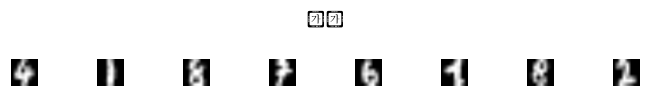

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing f

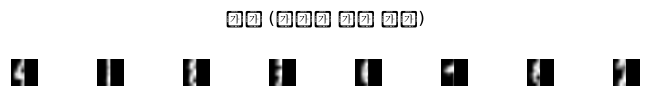

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


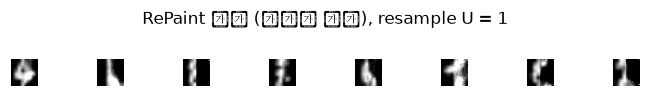

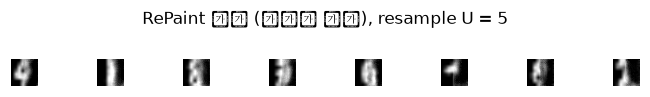

In [30]:
# --- 마스크 만들기 ---
xi, yi = next(iter(DataLoader(test_ds, batch_size=8, shuffle=True)))
xi, yi = xi.to(device), yi.to(device)

mask_half = torch.ones_like(xi); mask_half[:, :, :, 14:] = 0.0      # 오른쪽 절반 제거
mask_box  = torch.ones_like(xi); mask_box[:, :, 8:22, 8:22] = 0.0   # 가운데 사각형 제거

def show_masked(x, m, title):
    show_grid(x * m + (1 - m) * (-1.0), nrow=8, title=title)

show_grid(xi, nrow=8, title="원본")
show_masked(xi, mask_half, "입력 (오른쪽 절반 소실)")

for U in [1, 5]:
    torch.manual_seed(0)
    out = repaint(model, xi, mask_half, yi, w=2.0, resample=U)
    show_grid(out, nrow=8, title=f"RePaint 복원 (오른쪽 절반), resample U = {U}")

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from f

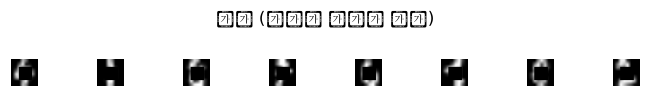

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48373 (\N{HANGUL SYLLABLE BOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


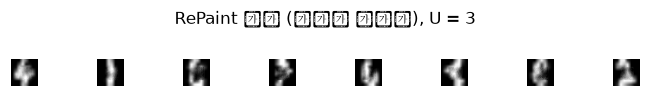

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 44057 (\N{HANGUL SYLLABLE GAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 50812 (\N{HANGUL SYLLABLE OEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51901 (\N{HANGUL SYLLABLE JJOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51208 (\N{HANGUL SYLLABLE JEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing f

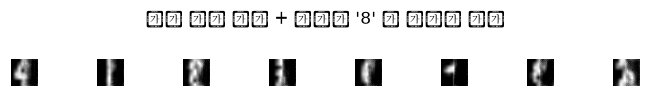

In [31]:
show_masked(xi, mask_box, "입력 (가운데 사각형 소실)")
torch.manual_seed(0)
out_box = repaint(model, xi, mask_box, yi, w=2.0, resample=3)
show_grid(out_box, nrow=8, title="RePaint 복원 (가운데 사각형), U = 3")

# 조건 라벨을 일부러 바꾸면? (원본과 다른 숫자로 채워 넣기)
y_wrong = torch.full_like(yi, 8)
torch.manual_seed(0)
out_w = repaint(model, xi, mask_half, y_wrong, w=3.0, resample=3)
show_grid(out_w, nrow=8, title="같은 왼쪽 절반 + 라벨을 '8' 로 강제한 복원")

In [32]:
# ===== 채점 5 =====
_m = mask_half[:4]
_x = xi[:4]
_o = repaint(model, _x, _m, yi[:4], w=2.0, resample=1)
assert torch.isfinite(_o).all(), "출력에 NaN/Inf 가 있습니다."
keep_err = ((_o - _x).abs() * _m).max().item()
assert keep_err < 1e-4, f"보존 영역(mask=1)이 원본과 달라졌습니다 (max err {keep_err:.5f}). 마스크 결합을 확인하세요."
gen_std = ((_o * (1 - _m)).std()).item()
assert gen_std > 0.2, "복원 영역이 거의 상수입니다. 모델 스텝이 반영되지 않았습니다."

# resample 이 실제로 반복 횟수를 늘리는지 (호출 횟수로 확인)
cnt = {"n": 0}
_orig_forward = model.forward
def _counting(x, t, y):
    cnt["n"] += 1
    return _orig_forward(x, t, y)
model.forward = _counting
_ = repaint(model, _x[:1], _m[:1], yi[:1], w=1.0, resample=1); n1 = cnt["n"]
cnt["n"] = 0
_ = repaint(model, _x[:1], _m[:1], yi[:1], w=1.0, resample=3); n3 = cnt["n"]
del model.forward          # 인스턴스 속성을 지워 원래 클래스 메서드로 복원
assert n3 > 2.5 * n1, f"resample 반복이 적용되지 않았습니다 (n1={n1}, n3={n3})."
print("문제 5 통과!")

문제 5 통과!


### 문제 5-4. 관찰 결과 서술 `[서술형]`

1. `resample = 1` 과 `5` 의 결과 차이를 설명하세요. 왜 반복이 도움이 되나요?
2. 알려진 영역을 `x_known` 원본 그대로(노이즈 없이) 결합하면 어떤 문제가 생길지 예상해 보세요.
3. 라벨을 '8' 로 강제한 마지막 실험에서, 마스크 조건과 클래스 조건이 충돌하면 어떤 결과가 나오나요?

**[답안]**

1. `resample=1`은 각 시간 단계에서 한 번만 역방향 갱신하므로 빠르지만, 알려진 영역과 새로 생성된 영역의 경계가 다소 부자연스러울 수 있습니다. `resample=5`는 같은 구간을 여러 번 노이즈화하고 복원하면서 경계 주변의 정보를 반복적으로 조정하므로 연결성이 좋아질 수 있습니다. 대신 모델 호출 횟수와 실행 시간이 증가합니다.
2. 알려진 영역을 현재 시각의 노이즈 수준에 맞추지 않고 원본 그대로 결합하면, 노이즈가 많은 미지 영역과 깨끗한 원본 영역 사이에 분포 불일치가 생깁니다. 그 결과 경계에 이음새나 밝기 차이가 나타나고, 모델이 예상하지 못한 상태를 입력받아 복원이 불안정해질 수 있습니다.
3. 마스크 조건은 보존 영역의 픽셀을 강제로 유지하지만, 클래스 조건은 생성 영역을 숫자 `8`의 형태로 유도합니다. 두 조건이 충돌하면 보존 영역은 원래 숫자의 일부로 남고, 결측 영역은 `8`의 획을 만들려는 타협적인 결과가 나타날 수 있습니다. 따라서 경계가 어색하거나 두 숫자의 형태가 섞인 이미지가 생성될 가능성이 있습니다.

---
## 문제 6. 확산 모델 기반 이상 탐지 (Anomaly Detection) &nbsp;&nbsp;`[15점]`

강의자료 **그림 7-17 (이상 징후 탐지 학습 프레임워크)**, **그림 7-18** 에 해당합니다.

핵심 아이디어:

1. 정상 데이터 분포를 학습한 확산 모델을 준비한다.
2. 검사할 이미지를 **중간 시각 $t_0$ 까지만** 노이즈로 덮는다 ($t_0 \ll T$).
3. 역방향 과정으로 복원한다 → 모델은 **정상 분포 위의 가장 가까운 이미지**를 되돌려 준다.
4. 원본과 복원본의 차이 $|x - \hat x|$ 가 곧 **anomaly map** 이 된다.

### 할 일
1. `partial_reconstruct(...)` : 이미지를 $t_0$ 까지 노이즈로 덮고 DDIM 으로 복원하세요.
2. `anomaly_score(...)` : 차이 맵을 `F.avg_pool2d` 로 부드럽게 만든 뒤 픽셀 **최댓값**을 반환하세요.
3. `auroc(scores, labels)` : 순위 기반(Mann–Whitney U) AUROC 를 구현하세요.
   $\mathrm{AUROC} = \dfrac{R_1 - n_1(n_1+1)/2}{n_1 n_0}$, $R_1$ = 양성(이상) 샘플들의 순위 합.
4. $t_0$ 를 바꿔가며 AUROC 를 그려 보고 서술형 문항에 답하세요.

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:1

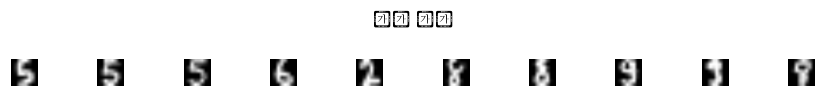

C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 48157 (\N{HANGUL SYLLABLE BALG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 54056 (\N{HANGUL SYLLABLE PAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\2055434537.py:21: UserWarning: Glyph 49341 (\N{HANGUL SYLLABLE SAB}) missing from

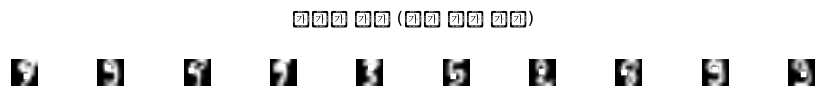

In [33]:
def add_defect(x, size=6, seed=0):
    # 밝은 정사각형 패치를 무작위 위치에 삽입 -> '결함' 이 있는 비정상 샘플
    g = torch.Generator().manual_seed(seed)
    out = x.clone()
    B = x.shape[0]
    for b in range(B):
        r = int(torch.randint(5, 28 - size - 5, (1,), generator=g))
        c = int(torch.randint(5, 28 - size - 5, (1,), generator=g))
        out[b, :, r:r + size, c:c + size] = 1.0
    return out

x_test, y_test = next(iter(DataLoader(test_ds, batch_size=128, shuffle=True)))
x_test, y_test = x_test.to(device), y_test.to(device)
x_norm = x_test[:64]
y_norm = y_test[:64]
x_anom = add_defect(x_test[64:], size=6, seed=3)
y_anom = y_test[64:]

show_grid(x_norm[:10], nrow=10, title="정상 샘플")
show_grid(x_anom[:10], nrow=10, title="비정상 샘플 (밝은 패치 삽입)")

In [34]:
@torch.no_grad()
def partial_reconstruct(model, x, y, t0=120, num_steps=25, w=2.0):
    B = x.shape[0]
    t = torch.full((B,), int(t0), device=x.device, dtype=torch.long)
    x_t = q_sample(x, t)
    return ddim_sample(model, y, num_steps=num_steps, eta=0.0, w=w,
                       x_init=x_t, t_start=int(t0))


def anomaly_map(x, x_rec, k=5):
    diff = (x - x_rec).abs()
    return F.avg_pool2d(diff, k, stride=1, padding=k // 2)


def anomaly_score(x, x_rec, k=5):
    return anomaly_map(x, x_rec, k=k).flatten(1).amax(dim=1)


def auroc(scores, labels):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    order = np.argsort(scores)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(scores) + 1)
    n1 = labels.sum()
    n0 = len(labels) - n1
    if n1 == 0 or n0 == 0:
        raise ValueError("AUROC requires both positive and negative samples.")
    rank_sum = ranks[labels == 1].sum()
    return float((rank_sum - n1 * (n1 + 1) / 2) / (n1 * n0))


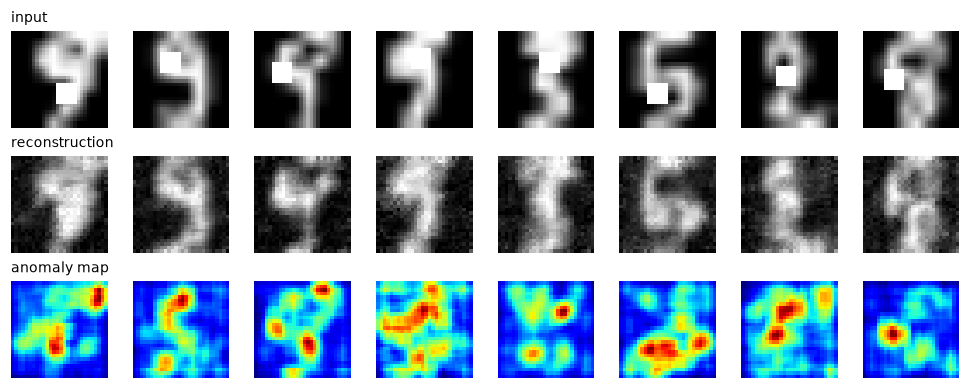

In [35]:
# --- anomaly map 시각화 ---
rec_a = partial_reconstruct(model, x_anom[:8], y_anom[:8], t0=120)
amap  = anomaly_map(x_anom[:8], rec_a)

fig, axes = plt.subplots(3, 8, figsize=(9, 3.6))
for j in range(8):
    axes[0, j].imshow(to_img(x_anom[j, 0].cpu()), cmap="gray"); axes[0, j].axis("off")
    axes[1, j].imshow(to_img(rec_a[j, 0].cpu()), cmap="gray");  axes[1, j].axis("off")
    axes[2, j].imshow(amap[j, 0].cpu(), cmap="jet");            axes[2, j].axis("off")
axes[0, 0].set_title("input", loc="left", fontsize=9)
axes[1, 0].set_title("reconstruction", loc="left", fontsize=9)
axes[2, 0].set_title("anomaly map", loc="left", fontsize=9)
plt.tight_layout(); plt.show()

t0 =  40   AUROC = 0.911
t0 =  80   AUROC = 0.797
t0 = 120   AUROC = 0.698
t0 = 200   AUROC = 0.560
t0 = 300   AUROC = 0.638


c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing

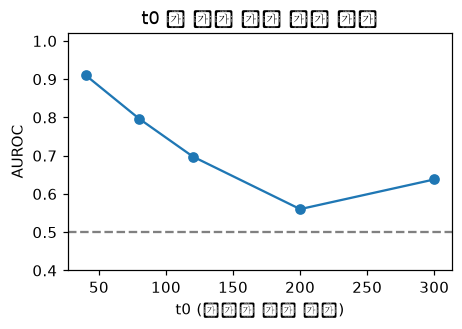

c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


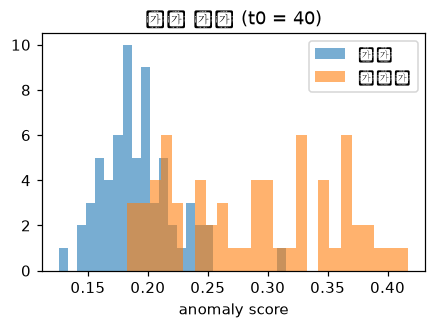

In [36]:
# --- t0 스윕 & AUROC ---
res = {}
for t0 in [40, 80, 120, 200, 300]:
    rn = partial_reconstruct(model, x_norm, y_norm, t0=t0)
    ra = partial_reconstruct(model, x_anom, y_anom, t0=t0)
    sn = anomaly_score(x_norm, rn).cpu().numpy()
    sa = anomaly_score(x_anom, ra).cpu().numpy()
    s = np.concatenate([sn, sa]); l = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    res[t0] = (auroc(s, l), sn, sa)
    print(f"t0 = {t0:3d}   AUROC = {res[t0][0]:.3f}")

plt.figure(figsize=(4.5, 2.8))
plt.plot(list(res.keys()), [v[0] for v in res.values()], marker="o")
plt.xlabel("t0 (노이즈 주입 시각)"); plt.ylabel("AUROC"); plt.ylim(0.4, 1.02)
plt.axhline(0.5, ls="--", c="gray"); plt.title("t0 에 따른 이상 탐지 성능"); plt.show()

best_t0 = max(res, key=lambda k: res[k][0])
_, sn, sa = res[best_t0]
plt.figure(figsize=(4.5, 2.8))
plt.hist(sn, bins=25, alpha=0.6, label="정상")
plt.hist(sa, bins=25, alpha=0.6, label="비정상")
plt.legend(); plt.xlabel("anomaly score"); plt.title(f"점수 분포 (t0 = {best_t0})"); plt.show()

In [37]:
# ===== 채점 6 =====
# (a) AUROC 함수 자체 검증
assert abs(auroc([0.1, 0.2, 0.3, 0.4], [0, 0, 1, 1]) - 1.0) < 1e-9
assert abs(auroc([0.4, 0.3, 0.2, 0.1], [0, 0, 1, 1]) - 0.0) < 1e-9
assert abs(auroc([1, 2, 3, 4], [0, 1, 0, 1]) - 0.75) < 1e-9

# (b) 복원 함수 검증
_r = partial_reconstruct(model, x_norm[:8], y_norm[:8], t0=120, num_steps=25)
assert _r.shape == x_norm[:8].shape and torch.isfinite(_r).all()
_diff = (_r - x_norm[:8]).abs().mean().item()
assert _diff > 0.02, f"복원본이 입력과 거의 같습니다 ({_diff:.4f}). 노이즈 주입(t0)을 확인하세요."
assert _diff < 0.8, f"복원본이 입력과 너무 다릅니다 ({_diff:.4f}). t_start=t0 로 전달했는지 확인하세요."

# (c) 이상 점수 검증
_s = anomaly_score(x_anom[:8], partial_reconstruct(model, x_anom[:8], y_anom[:8], t0=120))
assert _s.shape == (8,), "anomaly_score 는 (B,) 형태여야 합니다."

# (d) 실제 성능
best = max(v[0] for v in res.values())
print("최고 AUROC :", round(best, 3))
assert best > 0.70, "이상 탐지 성능이 너무 낮습니다. 점수 정의(최댓값)와 t0 를 확인하세요."
print("문제 6 통과!")

최고 AUROC : 0.911
문제 6 통과!


### 문제 6-4. 관찰 결과 서술 `[서술형]`

1. $t_0$ 가 너무 작을 때와 너무 클 때 각각 왜 AUROC 가 떨어지나요?
2. 이 실습에서는 편의상 MNIST 전체로 학습한 모델을 썼습니다.
   실제 산업 현장의 결함 검출에 적용하려면 학습 데이터를 어떻게 구성해야 할까요?
3. anomaly score 로 차이 맵의 **평균** 대신 **최댓값**을 쓴 이유는 무엇일까요?

**[답안]**

1. $t_0$가 너무 작으면 입력 이미지가 거의 보존되어 정상 이미지와 결함 이미지 모두 원본과 비슷하게 복원되므로 차이 점수의 구분력이 낮아집니다. 반대로 $t_0$가 너무 크면 정상 이미지도 많은 정보를 잃고 복원 과정에서 크게 바뀌어 정상 샘플의 점수까지 커집니다. 따라서 정상 구조는 유지하면서 결함만 제거할 수 있는 중간 정도의 $t_0$가 필요합니다.
2. 실제 산업 현장에서는 결함이 없는 정상 제품 이미지 위주로 학습 데이터를 구성하고, 조명·각도·위치·센서 노이즈의 정상 변동을 충분히 포함해야 합니다. 결함 이미지는 학습에 섞기보다 별도의 검증·테스트 세트로 보관해 AUROC, 정밀도, 재현율 등을 평가하는 것이 좋습니다. 제품 종류나 카메라 조건이 달라지면 조건별로 정상 분포를 다시 학습하거나 도메인별 보정을 적용해야 합니다.
3. 결함은 전체 이미지에서 작은 영역에만 나타날 수 있으므로 차이 맵의 평균을 사용하면 넓은 정상 영역에 의해 이상 신호가 희석될 수 있습니다. 최댓값은 국소적인 밝은 패치나 결함처럼 일부 픽셀에 집중된 큰 차이를 민감하게 반영합니다. 다만 센서 잡음에도 민감하므로 실제 시스템에서는 최댓값과 함께 상위 백분위수나 지역적 평균을 함께 검토하는 것이 안전합니다.

---
## 문제 7. CSDI 스타일 시계열 결측치 보간 (Imputation) &nbsp;&nbsp;`[10점]`

강의자료 **그림 7-24, 7-25 (CSDI)** 에 해당합니다.

* 시계열을 **조건 관측치** $x_0^{co}$ 와 **보간 대상** $x_0^{ta}$ 로 나눈다.
* 확산은 **보간 대상 위치에만** 적용: $x_t^{ta} = \sqrt{\bar\alpha_t}x_0^{ta}+\sqrt{1-\bar\alpha_t}\epsilon$
* 네트워크는 조건 관측치를 함께 입력받아 노이즈를 예측: $\epsilon_\theta(x_t^{ta}, t \mid x_0^{co})$
* 손실은 **대상 위치에서만** 계산: $\big\|\epsilon-\epsilon_\theta(x_t^{ta},t\mid x_0^{co})\big\|^2$

### 할 일
1. `ts_loss(net, x0, obs_mask)` : 대상 위치(`1-obs_mask`)에서만 MSE 를 계산하고
   **대상 위치의 개수로 나누어** 반환하세요.
2. `ts_impute(...)` : DDPM 역방향 한 스텝을 구현하고, 매 스텝 결과를 대상 위치로 제한하세요.
3. 결과를 baseline(선형 보간)과 비교하고 서술형 문항에 답하세요.

c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48521 (\N{HANGUL SYLLABLE BULG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\neton\anaconda3\envs\rl2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missin

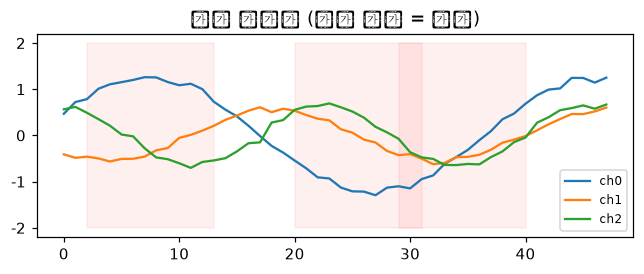

In [38]:
# ---------- 시계열용 확산 스케줄 (이미지와 별도) ----------
T_ts = 200
betas_ts = torch.linspace(1e-4, 0.1, T_ts).to(device)
alphas_ts = 1.0 - betas_ts
acp_ts = torch.cumprod(alphas_ts, dim=0)
acp_prev_ts = torch.cat([torch.ones(1, device=device), acp_ts[:-1]])
sqrt_acp_ts = acp_ts.sqrt()
sqrt_1macp_ts = (1 - acp_ts).sqrt()
sqrt_recip_alphas_ts = (1.0 / alphas_ts).sqrt()
post_var_ts = betas_ts * (1 - acp_prev_ts) / (1 - acp_ts)

def ts_q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    return extract(sqrt_acp_ts, t, x0.shape) * x0 + extract(sqrt_1macp_ts, t, x0.shape) * noise

# ---------- 합성 다변량 시계열 ----------
K, L = 3, 48

def make_series(n, seed=0):
    g = torch.Generator().manual_seed(seed)
    tt = torch.linspace(0, 1, L)[None, None, :]
    base_f = 1 + 2 * torch.rand(n, 1, 1, generator=g)
    mult = 1 + 0.35 * torch.arange(K).reshape(1, K, 1)
    ph = 2 * math.pi * torch.rand(n, K, 1, generator=g)
    amp = 0.5 + torch.rand(n, K, 1, generator=g)
    x = amp * torch.sin(2 * math.pi * base_f * mult * tt + ph) + 0.05 * torch.randn(n, K, L, generator=g)
    return x

def make_obs_mask(n, gap=12, seed=0):
    # 각 채널마다 길이 gap 의 연속 구간이 결측 (obs_mask = 1 이 관측된 위치)
    g = torch.Generator().manual_seed(seed)
    m = torch.ones(n, K, L)
    start = torch.randint(0, L - gap + 1, (n, K), generator=g)
    idx = start[..., None] + torch.arange(gap)
    m.scatter_(2, idx, 0.0)
    return m

X_train = make_series(8192, seed=1)
M_train = make_obs_mask(8192, seed=1)
X_val   = make_series(256, seed=99).to(device)
M_val   = make_obs_mask(256, seed=99).to(device)
ts_dl = DataLoader(TensorDataset(X_train, M_train), batch_size=128, shuffle=True, drop_last=True)

plt.figure(figsize=(7, 2.4))
for k in range(K):
    plt.plot(X_val[0, k].cpu(), label=f"ch{k}")
    miss = (M_val[0, k] == 0).cpu().numpy()
    plt.fill_between(np.arange(L), -2, 2, where=miss, color="red", alpha=0.06)
plt.legend(fontsize=8); plt.title("합성 시계열 (붉은 구간 = 결측)"); plt.show()

In [39]:
# ---------- 시계열용 노이즈 예측 네트워크 (제공 코드) ----------
class TSBlock(nn.Module):
    def __init__(self, ch, dilation):
        super().__init__()
        self.emb = nn.Linear(ch, ch)
        self.conv = nn.Conv1d(ch, 2 * ch, 3, padding=dilation, dilation=dilation)
        self.proj = nn.Conv1d(ch, ch, 1)
    def forward(self, x, emb):
        h = x + self.emb(emb)[:, :, None]
        a, b = self.conv(h).chunk(2, dim=1)
        h = torch.tanh(a) * torch.sigmoid(b)          # WaveNet 스타일 gated activation
        return x + self.proj(h)

class TSNet(nn.Module):
    def __init__(self, ch=96, n_layers=5):
        super().__init__()
        # 입력 채널: [노이즈가 씌워진 대상, 조건 관측치, 관측 마스크] = 3K
        self.inp = nn.Conv1d(3 * K, ch, 1)
        self.temb = nn.Sequential(SinusoidalPosEmb(ch), nn.Linear(ch, ch), nn.SiLU(), nn.Linear(ch, ch))
        self.blocks = nn.ModuleList([TSBlock(ch, 2 ** i) for i in range(n_layers)])
        self.out = nn.Sequential(nn.SiLU(), nn.Conv1d(ch, ch, 1), nn.SiLU(), nn.Conv1d(ch, K, 1))
    def forward(self, x_target, cond, obs_mask, t):
        h = self.inp(torch.cat([x_target, cond, obs_mask], dim=1))
        emb = self.temb(t)
        for blk in self.blocks:
            h = blk(h, emb)
        return self.out(h)

ts_net = TSNet().to(device)
print("파라미터 수 : %.2fM" % (sum(p.numel() for p in ts_net.parameters()) / 1e6))

파라미터 수 : 0.40M


In [40]:
def ts_loss(net, x0, obs_mask):
    B = x0.shape[0]
    tgt_mask = 1.0 - obs_mask
    t = torch.randint(0, T_ts, (B,), device=x0.device).long()
    noise = torch.randn_like(x0)
    x_t = ts_q_sample(x0, t, noise)
    pred = net(x_t * tgt_mask, x0 * obs_mask, obs_mask, t)
    squared_error = (pred - noise).square() * tgt_mask
    return squared_error.sum() / tgt_mask.sum().clamp_min(1.0)


In [41]:
TS_EPOCHS = 40
opt_ts = torch.optim.Adam(ts_net.parameters(), lr=2e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt_ts, TS_EPOCHS)

ts_net.train()
t0 = time.time()
for ep in range(TS_EPOCHS):
    run, n = 0.0, 0
    for xb, mb in ts_dl:
        xb, mb = xb.to(device), mb.to(device)
        opt_ts.zero_grad(set_to_none=True)
        loss = ts_loss(ts_net, xb, mb)
        loss.backward(); opt_ts.step()
        run += loss.item() * xb.size(0); n += xb.size(0)
    sched.step()
    if (ep + 1) % 5 == 0 or ep == 0:
        print(f"epoch {ep+1:2d}/{TS_EPOCHS}  loss = {run/n:.4f}  ({time.time()-t0:.0f}s)")
ts_net.eval()

epoch  1/40  loss = 0.2922  (2s)
epoch  5/40  loss = 0.0769  (9s)
epoch 10/40  loss = 0.0655  (18s)
epoch 15/40  loss = 0.0559  (27s)
epoch 20/40  loss = 0.0511  (37s)
epoch 25/40  loss = 0.0434  (46s)
epoch 30/40  loss = 0.0426  (54s)
epoch 35/40  loss = 0.0381  (63s)
epoch 40/40  loss = 0.0403  (72s)


TSNet(
  (inp): Conv1d(9, 96, kernel_size=(1,), stride=(1,))
  (temb): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=96, out_features=96, bias=True)
    (2): SiLU()
    (3): Linear(in_features=96, out_features=96, bias=True)
  )
  (blocks): ModuleList(
    (0): TSBlock(
      (emb): Linear(in_features=96, out_features=96, bias=True)
      (conv): Conv1d(96, 192, kernel_size=(3,), stride=(1,), padding=(1,))
      (proj): Conv1d(96, 96, kernel_size=(1,), stride=(1,))
    )
    (1): TSBlock(
      (emb): Linear(in_features=96, out_features=96, bias=True)
      (conv): Conv1d(96, 192, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
      (proj): Conv1d(96, 96, kernel_size=(1,), stride=(1,))
    )
    (2): TSBlock(
      (emb): Linear(in_features=96, out_features=96, bias=True)
      (conv): Conv1d(96, 192, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
      (proj): Conv1d(96, 96, kernel_size=(1,), stride=(1,))
    )
    (3): TSBlock(
      (e

In [42]:
@torch.no_grad()
def ts_impute(net, x_obs, obs_mask):
    # x_obs : (B,K,L) 관측값이 들어 있는 시계열 (결측 위치 값은 사용하지 않음)
    B = x_obs.shape[0]
    tgt = 1.0 - obs_mask
    cond = x_obs * obs_mask
    x = torch.randn_like(x_obs) * tgt
    for i in reversed(range(T_ts)):
        t = torch.full((B,), i, device=x_obs.device, dtype=torch.long)
        eps = net(x * tgt, cond, obs_mask, t)
        mean = extract(sqrt_recip_alphas_ts, t, x.shape) * (
            x - extract(betas_ts, t, x.shape) / extract(sqrt_1macp_ts, t, x.shape) * eps
        )
        if i > 0:
            x_prev = mean + extract(post_var_ts, t, x.shape).sqrt() * torch.randn_like(x)
        else:
            x_prev = mean
        x = x_prev * tgt
    return cond + x * tgt


In [43]:
# ===== 채점 7 =====
# (a) 손실 정규화 검증 : 대상 비율이 달라도 초기 손실은 1 근처여야 한다
class _ZeroNet(nn.Module):
    def forward(self, xt, cond, m, t): return torch.zeros_like(xt)
zn = _ZeroNet().to(device)
_x = torch.randn(512, K, L, device=device)
for gap in [12, 36]:
    _m = make_obs_mask(512, gap=gap, seed=7).to(device)
    lv = ts_loss(zn, _x, _m).item()
    frac = (1 - _m).mean().item()
    print(f"결측 비율 {frac:.2f} -> 초기 손실 {lv:.3f}")
    assert 0.75 < lv < 1.3, "대상 위치 개수로 정규화했는지 확인하세요 (전체 원소 수로 나누면 값이 작아집니다)."

# (b) 보간 결과 검증
xi_ = X_val[:64]; mi_ = M_val[:64]
imp = ts_impute(ts_net, xi_ * mi_, mi_)
assert imp.shape == xi_.shape and torch.isfinite(imp).all()
obs_err = ((imp - xi_).abs() * mi_).max().item()
assert obs_err < 1e-5, "관측 위치의 값이 바뀌었습니다. x = x * tgt / cond + x*tgt 를 확인하세요."

tgt_ = 1 - mi_
mae_diff = (((imp - xi_).abs() * tgt_).sum() / tgt_.sum()).item()

# baseline : 선형 보간
def linear_interp_baseline(x, m):
    out = x.clone().cpu().numpy(); mm = m.cpu().numpy()
    B_ = out.shape[0]
    for b in range(B_):
        for k in range(K):
            obs_idx = np.where(mm[b, k] == 1)[0]
            out[b, k] = np.interp(np.arange(L), obs_idx, out[b, k][obs_idx])
    return torch.from_numpy(out).to(x.device)

base = linear_interp_baseline(xi_ * mi_, mi_)
mae_base = (((base - xi_).abs() * tgt_).sum() / tgt_.sum()).item()
print(f"MAE(결측 구간)  확산모델 = {mae_diff:.4f}   선형보간 = {mae_base:.4f}")
assert mae_diff < mae_base, "확산 모델 보간이 선형 보간보다 나빠서는 안 됩니다. 학습/샘플링을 확인하세요."
print("문제 7 통과!")

결측 비율 0.25 -> 초기 손실 0.983
결측 비율 0.75 -> 초기 손실 0.997
MAE(결측 구간)  확산모델 = 0.0944   선형보간 = 0.6503
문제 7 통과!


C:\Users\neton\AppData\Local\Temp\ipykernel_28452\411479208.py:21: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\411479208.py:21: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\411479208.py:21: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\411479208.py:21: UserWarning: Glyph 50521 (\N{HANGUL SYLLABLE ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\411479208.py:21: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\neton\AppData\Local\Temp\ipykernel_28452\411479208.py:21: UserWar

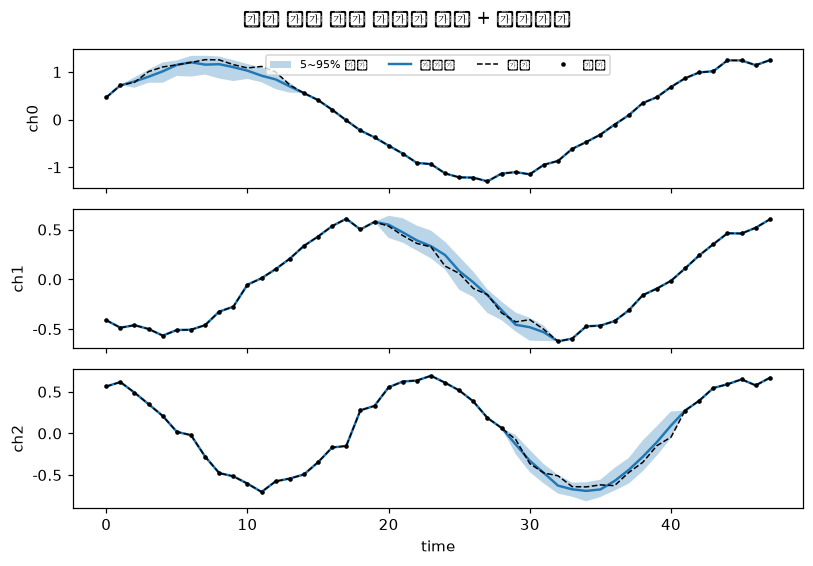

In [44]:
# --- 여러 번 샘플링해서 불확실성 구간 그리기 (그림 7-26 TimeGrad 스타일) ---
N_SAMP = 20
idx = 0
xs = X_val[idx:idx + 1].repeat(N_SAMP, 1, 1)
ms = M_val[idx:idx + 1].repeat(N_SAMP, 1, 1)
samples_ts = ts_impute(ts_net, xs * ms, ms).cpu().numpy()

fig, axes = plt.subplots(K, 1, figsize=(7.5, 5.2), sharex=True)
gt = X_val[idx].cpu().numpy(); mk = M_val[idx].cpu().numpy()
for k in range(K):
    ax = axes[k]
    lo, med, hi = np.percentile(samples_ts[:, k, :], [5, 50, 95], axis=0)
    ax.fill_between(np.arange(L), lo, hi, alpha=0.3, label="5~95% 구간")
    ax.plot(med, lw=1.6, label="중앙값")
    ax.plot(gt[k], "k--", lw=1.0, label="정답")
    ax.plot(np.where(mk[k] == 1)[0], gt[k][mk[k] == 1], "k.", ms=4, label="관측")
    ax.set_ylabel(f"ch{k}")
    if k == 0:
        ax.legend(fontsize=7, ncol=4)
plt.xlabel("time"); plt.suptitle("확산 모델 기반 시계열 보간 + 불확실성", fontsize=11)
plt.tight_layout(); plt.show()

### 문제 7-3. 관찰 결과 서술 `[서술형]`

1. 확산 모델 보간이 선형 보간보다 좋은 이유를 결과 그림을 근거로 설명하세요.
2. 불확실성 구간(5~95%)이 결측 구간 안에서 어떻게 변하나요? 왜 그럴까요?
3. 문제 5(RePaint)와 문제 7(CSDI)의 알고리즘적 공통점은 무엇인가요?

**[답안]**

1. 선형 보간은 양 끝 관측값을 직선으로 연결하기 때문에 주기적 진동이나 급격한 변화가 있는 시계열의 구조를 충분히 반영하지 못합니다. CSDI는 관측된 다른 시점과 채널의 조건을 사용해 학습한 시계열 분포에서 가능한 패턴을 복원하므로 진폭과 위상 변화를 더 자연스럽게 재현할 수 있습니다. 따라서 결과 그림에서 확산 모델의 곡선이 실제 시계열의 굴곡을 더 잘 따르는 경우가 많습니다.
2. 관측된 구간에서는 값이 조건으로 고정되므로 5~95% 불확실성 구간이 매우 좁게 모입니다. 결측 구간에서는 직접적인 관측 정보가 없기 때문에 여러 가능한 주기와 위상이 남아 불확실성 구간이 넓어집니다. 특히 결측 구간이 길거나 양 끝 관측값만으로 패턴을 정하기 어려울수록 예측 분산이 커집니다.
3. RePaint와 CSDI는 모두 관측된 조건을 별도로 보존하면서 결측 또는 생성 대상 위치에만 확산 역과정을 적용합니다. 매 단계에서 네트워크가 노이즈를 예측하고, 관측 마스크를 사용해 조건 영역이 바뀌지 않도록 강제한다는 점이 공통적입니다. 즉 공간 이미지에서는 픽셀 마스크를, 시계열에서는 시간·채널 마스크를 사용해 조건부 확산을 수행합니다.

---
## 마무리 — 7장 전체 정리 `[서술형]`

아래 표를 완성하고, 마지막 질문에 답하세요.

| 응용 | 조건 $c$ 는 무엇인가 | 조건을 어떻게 주입했나 |
|------|---------------------|------------------------|
| 클래스 조건부 생성 (문제 3) | 숫자 클래스 라벨 $y$ 또는 NULL_CLASS | 라벨 임베딩을 시간 임베딩과 더해 U-Net의 모든 ResBlock에 주입하고, CFG에서 조건부·무조건부 예측을 결합 |
| 이미지 편집 SDEdit (문제 4) | 거친 스케치 또는 가이드 이미지 | 가이드에 $t_0$까지 노이즈를 추가한 뒤, 그 상태를 DDIM 역과정의 초기값으로 사용 |
| 인페인팅 RePaint (문제 5) | 알려진 픽셀 영역과 보존 마스크 | 매 역방향 단계에서 알려진 영역을 원본의 해당 노이즈 수준으로 강제 대입하고, 미지 영역만 모델로 복원 |
| 이상 탐지 (문제 6) | 정상 데이터 분포와 검사 이미지 | 입력을 중간 시각까지 노이즈화한 뒤 정상 확산 모델로 복원하고, 입력과 복원본의 차이를 anomaly map으로 계산 |
| 시계열 보간 CSDI (문제 7) | 관측된 시간·채널 값과 관측 마스크 | 대상 결측 위치에만 확산을 적용하고, 네트워크 입력에 관측값과 마스크를 함께 넣어 조건부 노이즈를 예측 |

**종합 질문**

강의자료 7장에는 초해상도(그림 7-2), 의미적 분할(7-7), 비디오 생성(7-10),
포인트 클라우드(7-14), 분자 생성(7-45) 등 다양한 응용이 등장합니다.
이번 실습에서 배운 **조건 주입 방식 3가지**(네트워크 입력/임베딩, 가이던스, 샘플링 중 강제 대입) 중
하나를 골라, 위 응용 중 하나에 어떻게 적용할 수 있을지 3~5문장으로 설명하세요.

**[답안]**

초해상도에는 네트워크 입력과 임베딩을 이용한 조건 주입 방식을 적용할 수 있습니다. 저해상도 이미지를 별도의 인코더로 특징 벡터로 변환한 뒤, 이 특징을 U-Net의 시간 임베딩과 결합하거나 중간 feature map에 주입합니다. 확산 모델은 노이즈가 섞인 고해상도 이미지를 입력받아 저해상도 조건과 일치하는 세부 질감을 복원합니다. 이 방식은 전체 구조는 저해상도 입력에 맞추면서 고주파 세부 정보만 생성할 수 있다는 장점이 있습니다.

### 참고 문헌 (강의자료 출처)

* Ho et al., *Denoising Diffusion Probabilistic Models*, NeurIPS 2020
* Song et al., *Denoising Diffusion Implicit Models*, ICLR 2021
* Ho & Salimans, *Classifier-Free Diffusion Guidance*, 2022
* Meng et al., *SDEdit: Guided Image Synthesis and Editing with Stochastic Differential Equations*, ICLR 2021 — 그림 7-6
* Lugmayr et al., *RePaint: Inpainting using Denoising Diffusion Probabilistic Models*, CVPR 2022 — 그림 7-4, 7-5
* Wolleb et al., *Diffusion Models for Medical Anomaly Detection*, 2022 — 그림 7-17, 7-18
* Tashiro et al., *CSDI: Conditional Score-based Diffusion Models for Probabilistic Time Series Imputation*, NeurIPS 2021 — 그림 7-24, 7-25
* Rombach et al., *High-Resolution Image Synthesis with Latent Diffusion Models*, CVPR 2022 — 그림 7-3